# 07 · Exploratory Data Analysis: How the Data Is Distributed

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Study the distribution of job satisfaction, compare current and desired languages, and relate satisfaction to experience and education to employment.

**Data:** Stack Overflow Developer Survey (IBM Skills Network copy, 65,437 responses × 114 columns)

**Tools:** pandas, Matplotlib, Seaborn, SciPy (KDE)

### Key results
- Job satisfaction peaks at 8/10 (7,509 respondents); the 7/10 bar is inflated by median imputation.
- Job satisfaction and professional experience are weakly correlated (Pearson 0.104, Spearman 0.119).
- Full-time employment is dominated by Bachelor's (16,806) and Master's (11,011) degree holders.

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 06](06_eda_overview.ipynb) · [Project README](../README.md) · [08 →](08_eda_outliers.ipynb)

In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [12]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
print(df.dtypes)
print(df.shape) 
print(df.columns.tolist())
df.info()

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object
(65437, 114)
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWa

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [11]:
df['JobSat']= df['JobSat'].fillna(df['JobSat'].median())
df['Employment']= df['Employment'].fillna(df['Employment'].mode()[0])
df['YearsCodePro']= df['YearsCodePro'].fillna(df['YearsCodePro'].mode()[0])
df[['JobSat', 'YearsCodePro', 'Employment']].isna().sum()

JobSat          0
YearsCodePro    0
Employment      0
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [4]:
print(df['JobSat'].value_counts())
print(df['Employment'].value_counts())
print(df['YearsCodePro'].value_counts())

JobSat
8.0     7509
7.0     6379
6.0     3751
9.0     3626
10.0    2251
5.0     1956
3.0     1165
4.0     1130
2.0      772
0.0      311
1.0      276
Name: count, dtype: int64
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                 

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


In [14]:
%pip install scipy

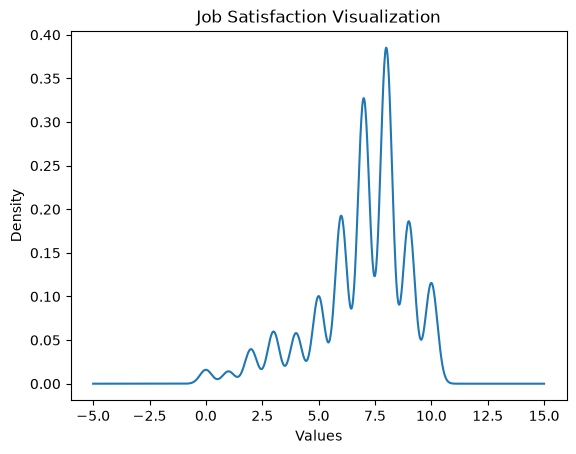

In [15]:
df['JobSat'].plot(kind='kde')
plt.title('Job Satisfaction Visualization')
plt.xlabel('Values')
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


**Approach:** both multi-select columns are split on `;` and exploded to one row per language; the top 10 languages by current use are then compared with how many respondents want to use them.

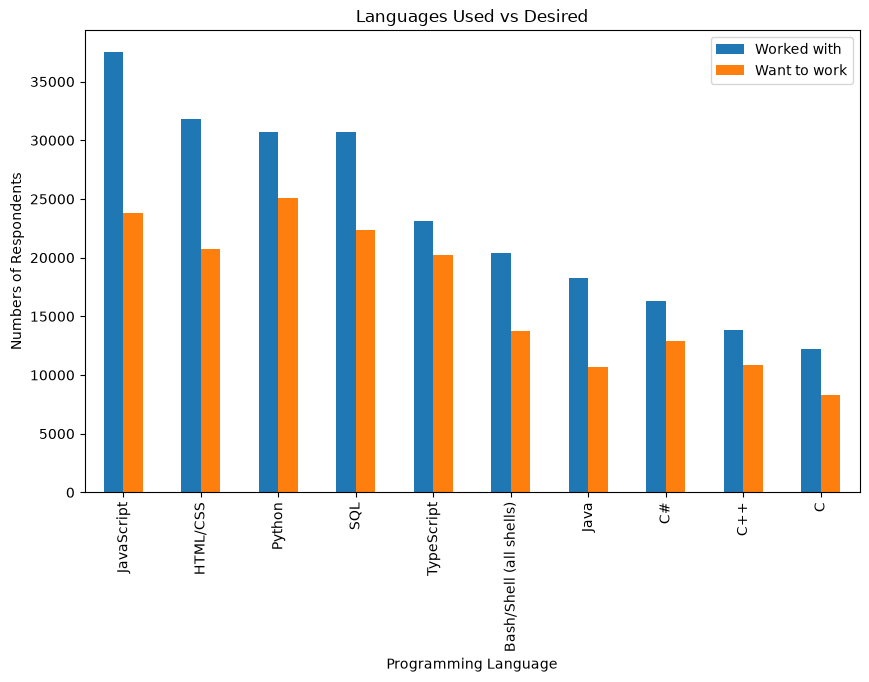

In [52]:
worked=df['LanguageHaveWorkedWith'].dropna()
worked= worked.str.split(';')
worked= worked.explode()
worked_counts= worked.value_counts()

want=df['LanguageWantToWorkWith'].dropna()
want= want.str.split(';')
want= want.explode()
want_counts= want.value_counts()

lang_df=pd.DataFrame({'Worked with': worked_counts, 'Want to work': want_counts})
top10=lang_df.sort_values(by='Worked with', ascending=False).head(10)

top10.plot(kind='bar', figsize=(10,6))
plt.title('Languages Used vs Desired')
plt.xlabel('Programming Language')
plt.ylabel('Numbers of Respondents')
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


RemoteWork                                          Hybrid (some remote, some in-person)  \
Country                                                                                    
Brazil                                                                               311   
Canada                                                                               631   
France                                                                              1041   
Germany                                                                             2421   
India                                                                               1196   
Netherlands                                                                          829   
Poland                                                                               458   
Ukraine                                                                              492   
United Kingdom of Great Britain and Northern Ir...                              

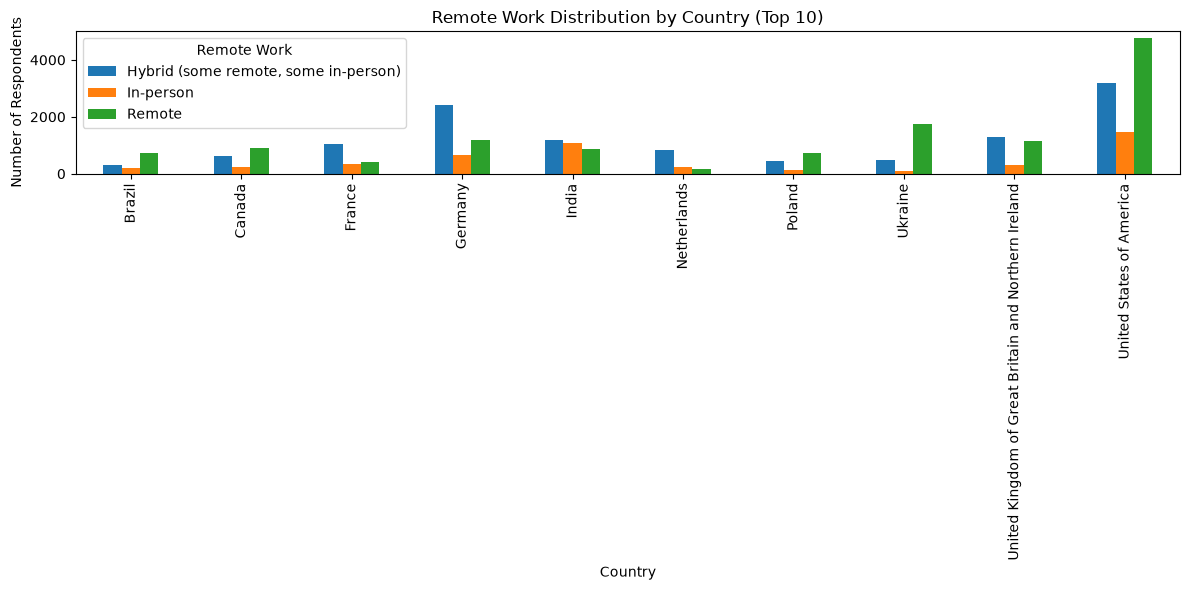

In [63]:
remote_df = df[['RemoteWork', 'Country']].dropna()
top_countries = remote_df['Country'].value_counts().head(10).index
remote_top = remote_df[remote_df['Country'].isin(top_countries)]

remote_ct = pd.crosstab(remote_top['Country'], remote_top['RemoteWork'])
print(remote_ct)

remote_ct.plot(kind='bar', figsize=(12, 6))
plt.title('Remote Work Distribution by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.legend(title='Remote Work')
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


**Approach:** `YearsCodePro` is converted to numbers ('Less than 1 year' = 0.5, 'More than 50 years' = 51). Pearson measures a linear relationship, Spearman a monotonic (rank) one.

In [64]:
exp_df = df[['JobSat', 'YearsCodePro']].copy()

# Convert text values to numbers
exp_df['YearsCodePro'] = exp_df['YearsCodePro'].replace({'Less than 1 year': 0.5, 'More than 50 years': 51})
exp_df['YearsCodePro'] = pd.to_numeric(exp_df['YearsCodePro'], errors='coerce')
exp_df = exp_df.dropna()

pearson = exp_df['JobSat'].corr(exp_df['YearsCodePro'], method='pearson')
spearman = exp_df['JobSat'].corr(exp_df['YearsCodePro'], method='spearman')
print('Pearson correlation:', round(pearson, 3))
print('Spearman correlation:', round(spearman, 3))

Pearson correlation: 0.104
Spearman correlation: 0.119

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      16806   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Primary/elementary school                                           160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   
Something else                                                      377   

Employment                                          Employed, full-time;Independent contractor, freelancer, or self-employed  \
EdLevel                                                                                                                  

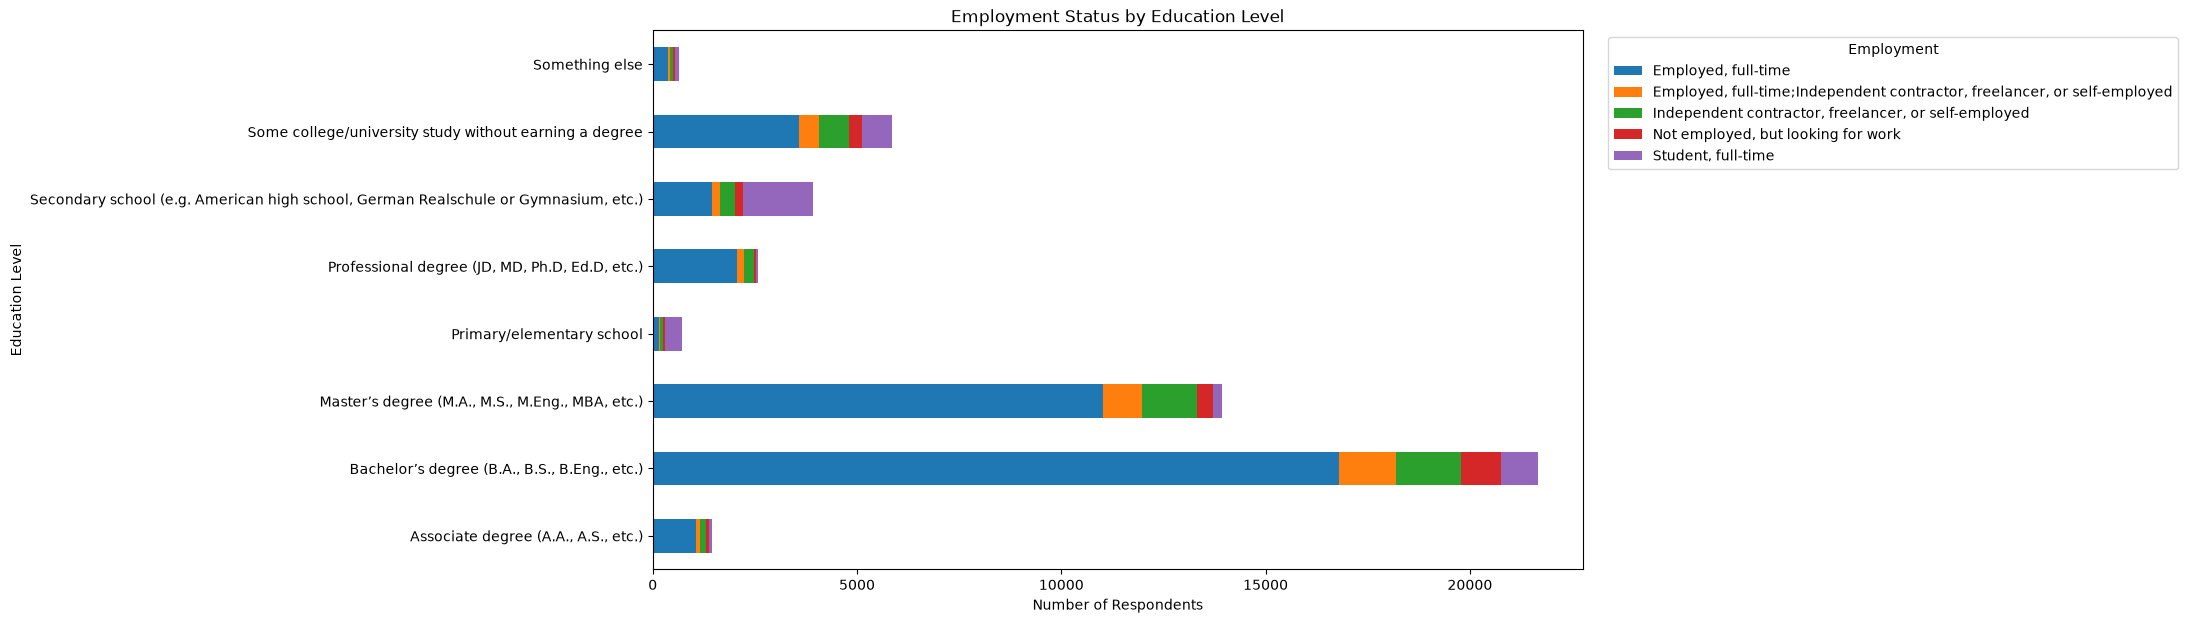

In [65]:
emp_ed = df[['Employment', 'EdLevel']].dropna()

# Keep the 5 most common employment statuses
top_emp = emp_ed['Employment'].value_counts().head(5).index
emp_ed = emp_ed[emp_ed['Employment'].isin(top_emp)]

cross_tab = pd.crosstab(emp_ed['EdLevel'], emp_ed['Employment'])
print(cross_tab)

cross_tab.plot(kind='barh', stacked=True, figsize=(12, 7))
plt.title('Employment Status by Education Level')
plt.xlabel('Number of Respondents')
plt.ylabel('Education Level')
plt.legend(title='Employment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [66]:
df_cleaned = df.drop_duplicates()
df_cleaned.to_csv('survey_data_lab13_cleaned.csv', index=False)
print('Saved', df_cleaned.shape[0], 'rows to survey_data_lab13_cleaned.csv')

Saved 65437 rows to survey_data_lab13_cleaned.csv

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
